## Trabajo Práctico 1:

In [1]:
import polars as pl

import pyprojroot

import matplotlib.pyplot as plt
import seaborn as sns

from plotnine import *

ROOT = pyprojroot.here()

### Carga de datos

In [2]:
atmosfera19 = pl.read_csv(ROOT / "2019" / "atmosfera.csv")
energia19 = pl.read_csv(ROOT / "2019" / "energia.csv")
lluvias19 = pl.read_csv(ROOT / "2019" / "lluvias.csv")

atmosfera20 = pl.read_csv(ROOT / "2020" / "atmosfera.csv")
energia20 = pl.read_csv(ROOT / "2020" / "energia.csv")
lluvias20 = pl.read_csv(ROOT / "2020" / "lluvias.csv")

atmosfera21 = pl.read_csv(ROOT / "2021" / "atmosfera.csv")
energia21 = pl.read_csv(ROOT / "2021" / "energia.csv")
lluvias21 = pl.read_csv(ROOT / "2021" / "lluvias.csv")

atmosfera22 = pl.read_csv(ROOT / "2022" / "atmosfera.csv")
energia22 = pl.read_csv(ROOT / "2022" / "energia.csv")
lluvias22 = pl.read_csv(ROOT / "2022" / "lluvias.csv")

atmosfera23 = pl.read_csv(ROOT / "2023" / "atmosfera.csv")
energia23 = pl.read_csv(ROOT / "2023" / "energia.csv")
lluvias23 = pl.read_csv(ROOT / "2023" / "lluvias.csv")

### Unimos las bases de datos en una única

In [3]:
datos2019 = atmosfera19.join(energia19, on = "fecha", how = "inner").join(lluvias19, on = "fecha", how = "inner")
datos2020 = atmosfera20.join(energia20, on = "fecha", how = "inner").join(lluvias20, on = "fecha", how = "inner")
datos2021 = atmosfera21.join(energia21, on = "fecha", how = "inner").join(lluvias21, on = "fecha", how = "inner")
datos2022 = atmosfera22.join(energia22, on = "fecha", how = "inner").join(lluvias22, on = "fecha", how = "inner")
datos2023 = atmosfera23.join(energia23, on = "fecha", how = "inner").join(lluvias23, on = "fecha", how = "inner")

datos = pl.concat([datos2019, datos2020, datos2021, datos2022, datos2023], how = "vertical")

## ¿Cuántas observaciones hay en el conjunto de datos? ¿Cuántas para cada año?

In [4]:
observaciones_total = datos.shape

En el conjunto de datos hay 1826 observaciones. En los años 2019, 2021, 2022 y 2023 se registraron 365 observaciones mientras que en el año 2020 hay 366 observaciones por ser un año bisiesto.

## ¿Hay datos faltantes?

In [5]:
datos.null_count()

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


No hay datos faltantes

## ¿Cuál es la cantidad total de lluvia caída en la zona? ¿Y cuánto se corresponde a cada año? Realice un gráfico de barras.

In [6]:
lluvia_total = datos["lluvia"].sum()
lluvia_total19 = datos2019["lluvia"].sum()
lluvia_total20 = datos2020["lluvia"].sum()
lluvia_total21 = datos2021["lluvia"].sum()
lluvia_total22 = datos2022["lluvia"].sum()
lluvia_total23 = datos2023["lluvia"].sum()

La cantidad total de lluvia caída en la zona es de 4327.79 milimetros. En el año 2019 llovío 346.6 milimetros, en 2020 811.59, en 2021 950.40, en 2022 1476.19 y en 2023 743.

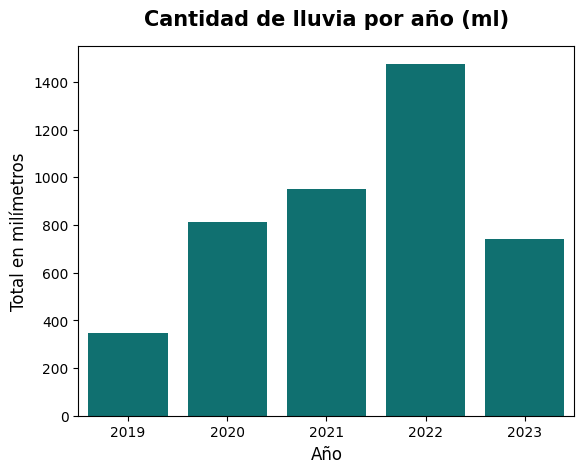

In [ ]:
# Agregamos una columna con el año
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.year()
    .alias("anio")
)

datos_agrupado_anio = datos.group_by("anio").agg(pl.col("lluvia").sum().alias("total"))

sns.barplot(x = "anio", y = "total", data = datos_agrupado_anio, color = "teal");
plt.title(
    "Cantidad de lluvia por año (mm)",
    fontsize = 15,
    fontweight = "bold",
    pad = 15
)

plt.xlabel("Año", fontsize=12)
plt.ylabel("Total en milímetros", fontsize=12);

## Visualice la cantidad de lluvia por mes y año en un gráfico de líneas.

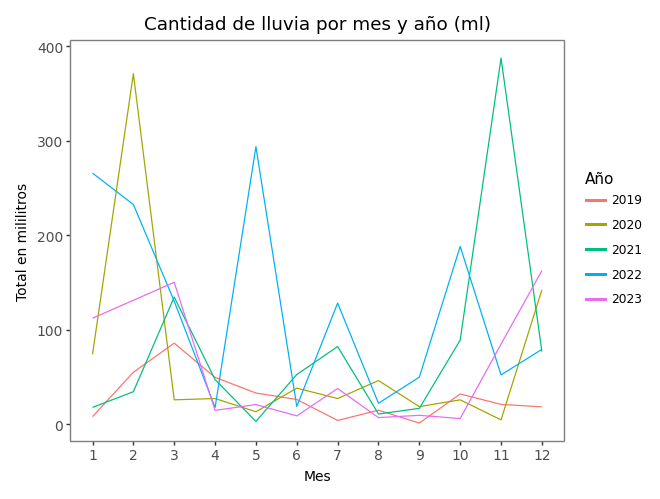

In [ ]:
# Agregamos una columna con el año
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.month()
    .alias("mes")
)

datos_agrupado_anio_mes = datos.group_by("anio", "mes").agg(pl.col("lluvia").sum().alias("total")).sort(["anio", "mes"])

grafico = (
    ggplot(datos_agrupado_anio_mes) + 
    aes(x="mes", y="total", color="factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks=range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de lluvia por mes y año (mm)",
        x = "Mes",
        y="Total en milimetros",
        color="Año"
    ) +
    theme(
        panel_grid_minor=element_blank(),
        panel_grid_major=element_blank(),
        axis_title_x=element_text(size=10),
        axis_title_y=element_text(size=10),
        axis_text=element_text(size=10)
    )
)

grafico

falta interpretar

## Obtenga uno o varios gráficos que muestre(n) la evolución de la temperatura mínima y máxima a lo largo del tiempo.

## Obtenga un gráfico que permita ver la asociación entre la temperatura mínima y máxima.

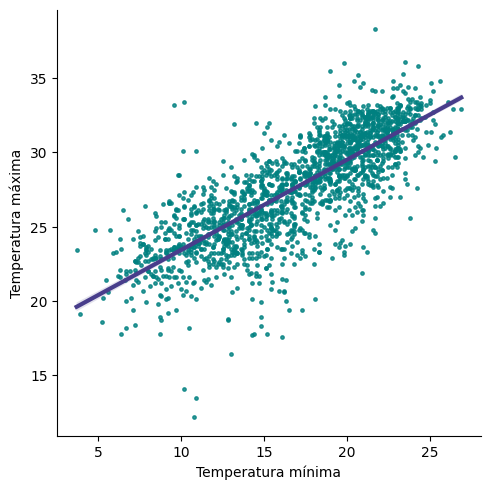

In [ ]:
g = sns.lmplot(data = datos, x = "t_min", y = "t_max",
    scatter_kws={"s": 6, "color": "teal"},
    line_kws={"color": "darkslateblue", "linewidth": 3}
)
g.set_xlabels("Temperatura mínima")
g.set_ylabels("Temperatura máxima");
# AGREGAR TïTLULO

interptreat

### Calcule la amplitud térmica, es decir, la diferencia entre la mayor y menor temperatura diaria.

In [22]:
datos = datos.with_columns(
    amplitud_termica = pl.col("t_max") - pl.col("t_min")
)